# Project Overview

This project estimates the causal impact of California Proposition 99, a tobacco control policy introduced in 1989, on per-capita cigarette sales. Using observational panel data from 39 U.S. states (1970–2000), the analysis constructs a counterfactual to estimate what California's cigarette sales would have been without the policy.

The project applies a causal inference method, such as **Synthetic Control**, validates the required assumptions, estimates the **Average Treatment Effect on the Treated (ATT)**, and visualizes the policy's impact over time. Finally, the results are interpreted while discussing potential limitations and threats to causal validity.

## Libraries Used

- **pandas** – Data loading, cleaning, and manipulation.
- **numpy** – Numerical computations.
- **matplotlib** – Data visualization.
- **statsmodels** – Difference-in-Differences (DiD) regression and statistical analysis.
- **SyntheticControlMethods** – Synthetic Control model for counterfactual estimation.
- **scikit-learn** – Data preprocessing and utility functions.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [101]:
df = pd.read_csv("data.csv")
df.head()

,state,year,cigsale,lnincome,beer,age15to24,retprice
0,Alabama,1970,89.8,NaN,NaN,0.178862,39.6
1,Alabama,1971,95.4,NaN,NaN,0.179928,42.7
2,Alabama,1972,101.1,9.498476,NaN,0.180994,42.3
3,Alabama,1973,102.9,9.550107,NaN,0.182060,42.1
4,Alabama,1974,108.2,9.537163,NaN,0.183126,43.1


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   state      1209 non-null   object 
 1   year       1209 non-null   int64  
 2   cigsale    1209 non-null   float64
 3   lnincome   1014 non-null   float64
 4   beer       546 non-null    float64
 5   age15to24  819 non-null    float64
 6   retprice   1209 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 66.2+ KB


In [103]:
df.shape

(1209, 7)

In [104]:
df.columns

Index(['state', 'year', 'cigsale', 'lnincome', 'beer', 'age15to24',
       'retprice'],
      dtype='object')

## Dataset Overview

The dataset contains annual panel data for 39 U.S. states from 1970 to 2000, resulting in 1,209 observations and 7 variables. It is used to evaluate the causal impact of California's Proposition 99, a tobacco control policy implemented in 1989.

### Dataset Shape

- Rows: 1,209
- Columns: 7

## Data Exploration

In [105]:
df.describe()

,year,cigsale,lnincome,beer,age15to24,retprice
count,1209.000000,1209.000000,1014.000000,546.000000,819.000000,1209.000000
mean,1985.000000,118.893218,9.861634,23.430403,0.175472,108.341935
std,8.947973,32.767404,0.170677,4.223190,0.015159,64.381986
min,1970.000000,40.700000,9.397450,2.500000,0.129448,27.300000
25%,1977.000000,100.900000,9.739134,20.900000,0.165816,50.000000
50%,1985.000000,116.300000,9.860844,23.300000,0.178121,95.500000
75%,1993.000000,130.500000,9.972765,25.100000,0.186660,158.400000
max,2000.000000,296.200000,10.486617,40.400000,0.203675,351.200000


The descriptive statistics show that the dataset covers the period 1970–2000. Per-capita cigarette sales (`cigsale`) average 118.89 packs, ranging from 40.7 to 296.2, indicating substantial variation across states and years. Retail cigarette prices (`retprice`) also vary considerably, suggesting differences in pricing policies over time and across states. Overall, the numerical variables exhibit sufficient variability for causal analysis.

In [106]:
df.isnull().sum()

,0
state,0
year,0
cigsale,0
lnincome,195
beer,663
age15to24,390
retprice,0


**Interpretation:** The predictor variables `lnincome`, `beer`, and `age15to24` contain missing values and will require preprocessing before model development.

In [107]:
df.duplicated().sum()

np.int64(0)

The dataset contains no duplicate records.

In [108]:
df["state"].unique()

array(['Alabama', 'Arkansas', 'California', 'Colorado', 'Connecticut',
       'Delaware', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
       'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Mexico', 'North Carolina', 'North Dakota',
       'Ohio', 'Oklahoma', 'Pennsylvania', 'Rhode Island',
       'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah',
       'Vermont', 'Virginia', 'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype=object)

In [109]:
df["state"].nunique()

39

The dataset consists of 39 U.S. states observed from 1970 to 2000. California is the treated state, while the other 38 states form the control group for causal analysis.

## Data Preprocessing

### Handling Missing Values

In [110]:
df.isnull().sum()

,0
state,0
year,0
cigsale,0
lnincome,195
beer,663
age15to24,390
retprice,0


### Interpolation
Dropping missing values can result in substantial data loss. Therefore, interpolation will be used to estimate missing values using the values before and after each missing observation, preserving the data trend.


In [111]:
df["lnincome"] = (
    df.groupby("state")["lnincome"]
      .transform(lambda x: x.interpolate().ffill().bfill())
)

In [112]:
df["age15to24"] = (
    df.groupby("state")["age15to24"]
    .transform(lambda x: x.interpolate())
)

In [113]:
df.drop(columns=["beer"], inplace=True)

In [114]:
df.isnull().sum()

,0
state,0
year,0
cigsale,0
lnincome,0
age15to24,0
retprice,0


 Missing values were handled using state-wise interpolation, while the `beer` variable was removed due to a large number of missing values.

## Defining Treated and Control Units

This step identifies the unit affected by the intervention and the units used for comparison.

- **Treated unit:** California, where Proposition 99 was implemented in 1989.
- **Control units:** The remaining 38 U.S. states that did not receive the intervention.

The treated and control groups are separated to construct the counterfactual and estimate the causal effect of the intervention.

In [115]:
treated_state = "California"

In [116]:
treated = df[df["state"] == treated_state]
control = df[df["state"] != treated_state]

print("Treated unit:", treated["state"].unique())
print("Number of control states:", control["state"].nunique())

Treated unit: ['California']
Number of control states: 38


## Exploratory Data Analysis (EDA)

**EDA** is used to explore the dataset, identify patterns, and visualize trends before applying the causal model. In this project, it focuses on comparing cigarette sales trends between California and control states before and after Proposition 99.

 Cigarette sales declined in both California and control states after 1989. However, California experienced a much larger decline compared with the control group, suggesting a potential effect of Proposition 99 beyond the general downward trend observed across states.

In [117]:
df.dtypes

,0
state,object
year,int64
cigsale,float64
lnincome,float64
age15to24,float64
retprice,float64


### Variables and Data Types

The dataset contains object, integer, and float data types. Object variables represent categorical information, integer variables represent discrete values, and float variables represent continuous numerical values.

### Trend Analysis

Cigarette sales trends were visualized to compare California with control states before and after Proposition 99 in 1989. This helps identify whether California experienced a larger decline than the general trend observed across other states.

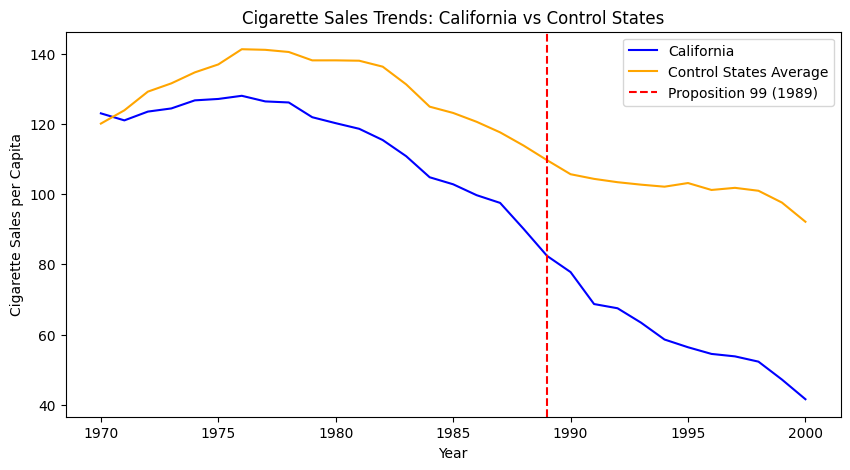

In [118]:
control_trend = control.groupby("year")["cigsale"].mean()
california_trend = treated.groupby("year")["cigsale"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    california_trend.index,
    california_trend.values,
    color="blue",
    label="California"
)

plt.plot(
    control_trend.index,
    control_trend.values,
    color="orange",
    label="Control States Average"
)

plt.axvline(
    x=1989,
    linestyle="--",
    color="red",
    label="Proposition 99 (1989)"
)

plt.xlabel("Year")
plt.ylabel("Cigarette Sales per Capita")
plt.title("Cigarette Sales Trends: California vs Control States")

plt.legend()
plt.show()

 Cigarette sales declined in both California and control states after 1989. However, California experienced a much larger decline compared with the control group, suggesting a potential effect of Proposition 99 beyond the general downward trend observed across states.

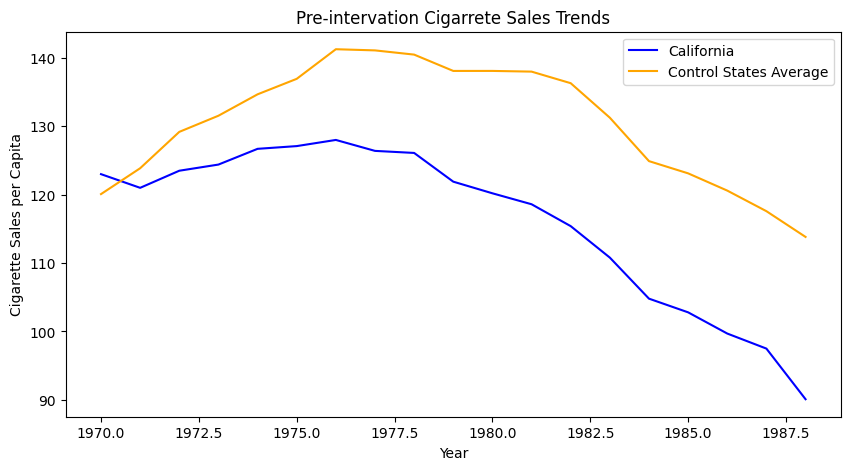

In [119]:
pre_period = df[df["year"] < 1989]

control_pre = (
    pre_period[pre_period["state"] != treated_state]
    .groupby("year")["cigsale"]
    .mean()
)

california_pre = (
    pre_period[pre_period["state"] == "California"]
    .groupby("year")["cigsale"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    california_pre.index,
    california_pre.values,
    color="blue",
    label="California"
)

plt.plot(
    control_pre.index,
    control_pre.values,
    color="orange",
    label="Control States Average"
)

plt.xlabel("Year")
plt.ylabel("Cigarette Sales per Capita")
plt.title("Pre-intervation Cigarrete Sales Trends")
plt.legend()
plt.show()

 Before the intervention, both California and the control states showed a downward trend, although California experienced a slightly faster decline.

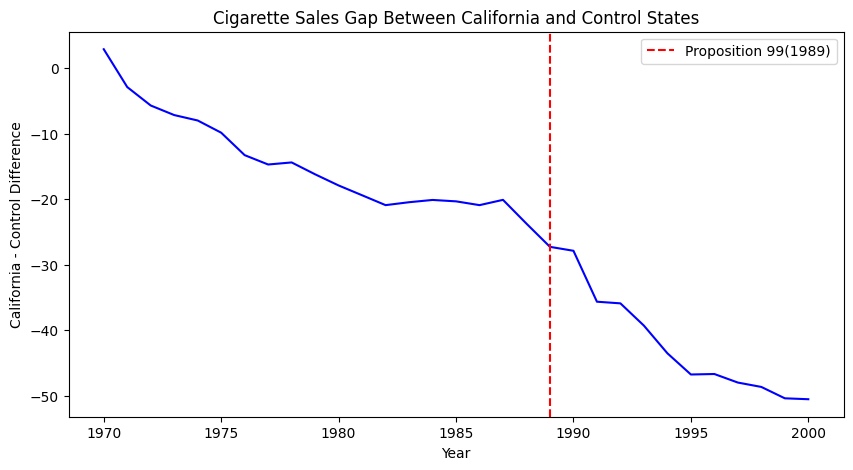

In [120]:
gap = california_trend - control_trend

plt.figure(figsize=(10,5))

plt.plot(
    gap.index,
    gap.values,
    color="blue"
)

plt.axvline(
    x=1989,
    linestyle="--",
    color="red",
    label="Proposition 99(1989)"
)

plt.xlabel("Year")
plt.ylabel("California - Control Difference")
plt.title("Cigarette Sales Gap Between California and Control States")
plt.legend()
plt.show()

The gap between California and the control states increased after 1989. This indicates that cigarette sales declined more in California than in the control states following Proposition 99, suggesting a potential treatment effect.

## Counterfactual Estimation

**Counterfactual estimation** constructs a synthetic version of California to estimate what cigarette sales would have been if Proposition 99 had not been implemented. By comparing the actual outcomes with the synthetic control after 1989, it can be estimated whether the policy had a causal effect on cigarette sales.

### Synthetic Control Method

**Synthetic Control Method (SCM)** is a causal inference method that creates a weighted combination of untreated units to estimate the counterfactual outcome for the treated unit.

In [121]:
treated = df[df["state"] == "California"].copy()
control = df[df["state"] != "California"].copy()

pre = df[df["year"] < 1989]

In [122]:
california_pre = (
    pre[pre["state"] == "California"]
    .set_index("year")["cigsale"]
)

controls_pre = (
    pre[pre["state"] != "California"]
    .pivot(
        index="year",
        columns="state",
        values="cigsale"
    )
)

controls_pre = controls_pre.dropna(axis=1)

In [123]:
common_years = california_pre.index.intersection(
    controls_pre.index
)

y = california_pre.loc[common_years].values

X = controls_pre.loc[common_years].values

In [124]:
n_controls = X.shape[1]


def objective(weights):
    synthetic = X @ weights
    return np.mean((y - synthetic) ** 2)


initial_weights = np.ones(n_controls) / n_controls


constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}


bounds = [(0, 1)] * n_controls


result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 2000,
        "ftol": 1e-10
    }
)


weights = result.x


weights_df = pd.DataFrame({
    "state": controls_pre.columns,
    "weight": weights
})


weights_df = weights_df.sort_values(
    "weight",
    ascending=False
)


print(weights_df)

             state        weight
32            Utah  3.939043e-01
17         Montana  2.318438e-01
19          Nevada  2.049244e-01
3      Connecticut  1.090893e-01
20   New Hampshire  4.542696e-02
2         Colorado  1.481120e-02
4         Delaware  1.633730e-12
7         Illinois  1.557207e-12
10          Kansas  1.330516e-12
18        Nebraska  1.313227e-12
14       Minnesota  1.082009e-12
31           Texas  1.008866e-12
24            Ohio  8.803537e-13
9             Iowa  7.960326e-13
35   West Virginia  6.651191e-13
26    Pennsylvania  6.632808e-13
21      New Mexico  6.166181e-13
13           Maine  5.160440e-13
36       Wisconsin  3.963998e-13
37         Wyoming  2.565715e-13
12       Louisiana  2.563048e-13
23    North Dakota  2.261543e-13
29    South Dakota  2.309247e-14
5          Georgia  0.000000e+00
0          Alabama  0.000000e+00
1         Arkansas  0.000000e+00
6            Idaho  0.000000e+00
16        Missouri  0.000000e+00
8          Indiana  0.000000e+00
11        

In [125]:
print(result.success)
print(result.message)
print(weights.sum())

True
Optimization terminated successfully
1.0000000000121856


In [126]:
weights_df_clean = weights_df[
    weights_df["weight"] > 0.001
].copy()

print(weights_df_clean)

            state    weight
32           Utah  0.393904
17        Montana  0.231844
19         Nevada  0.204924
3     Connecticut  0.109089
20  New Hampshire  0.045427
2        Colorado  0.014811


In [127]:
controls_all = (
    control
    .pivot(
        index="year",
        columns="state",
        values="cigsale"
    )
)

controls_all = controls_all[controls_pre.columns]

synthetic_california = controls_all @ weights

In [128]:
california = (
    treated
    .set_index("year")["cigsale"]
)

results = pd.DataFrame({
    "Actual_California": california,
    "Synthetic_California": synthetic_california
})

In [129]:
results["Treatment_Effect"] = (
    results["Actual_California"]
    - results["Synthetic_California"]
)

In [130]:
results

,Actual_California,Synthetic_California,Treatment_Effect
year,,,
1970,123.0,117.424036,5.575964
1971,121.0,119.822967,1.177033
1972,123.5,124.646381,-1.146381
1973,124.4,124.367230,0.032770
1974,126.7,126.473710,0.226290
1975,127.1,126.773816,0.326184
1976,128.0,128.469134,-0.469134
1977,126.4,126.684566,-0.284566
1978,126.1,126.144888,-0.044888


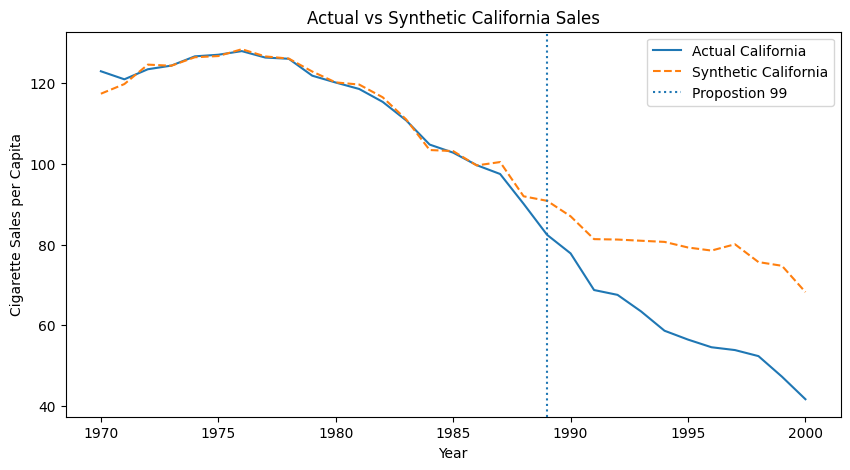

In [131]:
plt.figure(figsize=(10,5))

plt.plot(
    results.index,
    results["Actual_California"],
    label="Actual California"
)

plt.plot(
    results.index,
    results["Synthetic_California"],
    linestyle="--",
    label="Synthetic California"
)

plt.axvline(
    x=1989,
    linestyle=":",
    label="Propostion 99"
)

plt.xlabel("Year")
plt.ylabel("Cigarette Sales per Capita")
plt.title("Actual vs Synthetic California Sales")
plt.legend()

plt.show()

Synthetic California also decreased after Proposition 99, but actual California decreased much more significantly. This suggests that Proposition 99 contributed to the additional decline in cigarette sales.

In [132]:
post_results = results[results.index >= 1989]

average_effect = post_results["Treatment_Effect"].mean()

print("Average Treatment Effect:", average_effect)

Average Treatment Effect: -19.513647449753993


The **average treatment effect** after Proposition 99 was -19.51. This means that actual cigarette sales in California were, on average, about 19.51 units per capita lower than the estimated counterfactual sales.

### Pre-Treatment RMSPE

In [133]:
pre_results = results[results.index < 1989]

pre_rmspe = np.sqrt(
    np.mean(
        (
            pre_results["Actual_California"]
            - pre_results["Synthetic_California"]
        ) ** 2
    )
)

print("Pre-treatment RMSPE:", pre_rmspe)

Pre-treatment RMSPE: 1.6564004004233137


The **pre-treatment RMSPE** was 1.66, indicating a small difference between actual and synthetic California before 1989.

## Placebo Test

A **placebo test** compares California's treatment effect with the effects estimated for other states. This helps check whether California's effect is unusually large after 1989.

In [134]:
def synthetic_control(treated_state, df, intervention_year=1989):

    pre = df[df["year"] < intervention_year]

    treated_pre = (
        pre[pre["state"] == treated_state]
        .set_index("year")["cigsale"]
    )

    controls_pre = (
        pre[pre["state"] != treated_state]
        .pivot(
            index="year",
            columns="state",
            values="cigsale"
        )
        .dropna(axis=1)
    )

    common_years = treated_pre.index.intersection(
        controls_pre.index
    )

    y = treated_pre.loc[common_years].values
    X = controls_pre.loc[common_years].values

    n_controls = X.shape[1]

    def objective(weights):
        synthetic = X @ weights
        return np.mean((y - synthetic) ** 2)

    initial_weights = np.ones(n_controls) / n_controls

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    bounds = [(0, 1)] * n_controls

    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 2000,
            "ftol": 1e-10
        }
    )

    weights = result.x

    controls_all = (
        df[df["state"] != treated_state]
        .pivot(
            index="year",
            columns="state",
            values="cigsale"
        )
    )

    controls_all = controls_all[controls_pre.columns]

    synthetic = controls_all @ weights

    actual = (
        df[df["state"] == treated_state]
        .set_index("year")["cigsale"]
    )

    results = pd.DataFrame({
        "Actual": actual,
        "Synthetic": synthetic
    })

    return results

In [135]:
states = df["state"].unique()

placebo_effects = []

for state in states:

    if state == "California":
        continue

    placebo_results = synthetic_control(state, df)

    post = placebo_results[
        placebo_results.index >= 1989
    ]

    effect = (
        post["Actual"] - post["Synthetic"]
    ).mean()

    placebo_effects.append({
        "state": state,
        "effect": effect
    })

placebo_df = pd.DataFrame(placebo_effects)

In [136]:
placebo_df

,state,effect
0,Alabama,2.290445
1,Arkansas,-0.871929
2,Colorado,-5.960581
3,Connecticut,-13.441760
4,Delaware,9.873264
5,Georgia,-8.806808
6,Idaho,1.930630
7,Illinois,-0.896267
8,Indiana,14.107369
9,Iowa,3.968257


In [137]:
california_effect = results[
    results.index >= 1989
]["Treatment_Effect"].mean()

print(california_effect)

-19.513647449753993


In [138]:
placebo_df.loc[len(placebo_df)] = [
    "California",
    california_effect
]

In [139]:
placebo_df = placebo_df.sort_values(
    "effect"
)

print(placebo_df)

             state     effect
27    Rhode Island -25.471264
38      California -19.513647
34        Virginia -15.540418
32            Utah -14.458333
31           Texas -14.179965
3      Connecticut -13.441760
33         Vermont  -9.881374
5          Georgia  -8.806808
23    North Dakota  -6.054255
2         Colorado  -5.960581
14       Minnesota  -3.668273
22  North Carolina  -3.007127
13           Maine  -2.859060
21      New Mexico  -1.853917
10          Kansas  -1.414847
28  South Carolina  -0.905217
7         Illinois  -0.896267
1         Arkansas  -0.871929
20   New Hampshire   0.229170
24            Ohio   0.530979
19          Nevada   0.750954
37         Wyoming   0.814122
6            Idaho   1.930630
26    Pennsylvania   2.074143
0          Alabama   2.290445
12       Louisiana   3.847328
9             Iowa   3.968257
15     Mississippi   5.148190
29    South Dakota   6.979613
25        Oklahoma   7.421891
36       Wisconsin   7.680051
18        Nebraska   8.118700
16        

California had an average treatment effect of -19.51, which was more negative than most control states. However, Rhode Island had a larger negative **placebo effect**, indicating that the result is not completely unique to California.

In [140]:
placebo_results = []

for state in df["state"].unique():

    placebo = synthetic_control(state, df)

    pre = placebo[placebo.index < 1989]
    post = placebo[placebo.index >= 1989]

    pre_rmspe = np.sqrt(
        np.mean((pre["Actual"] - pre["Synthetic"]) ** 2)
    )

    post_rmspe = np.sqrt(
        np.mean((post["Actual"] - post["Synthetic"]) ** 2)
    )

    ratio = post_rmspe / pre_rmspe

    placebo_results.append({
        "state": state,
        "RMSPE_Ratio": ratio
    })

placebo_df = pd.DataFrame(placebo_results)

print(placebo_df.sort_values("RMSPE_Ratio", ascending=False))

             state  RMSPE_Ratio
17        Missouri    23.924402
35        Virginia    19.827629
2       California    12.439974
19        Nebraska    10.091402
6          Georgia     9.061642
32           Texas     8.178693
26        Oklahoma     8.126001
30    South Dakota     7.228469
28    Rhode Island     7.004230
36   West Virginia     6.816929
18         Montana     6.656431
37       Wisconsin     6.116174
34         Vermont     6.049465
13       Louisiana     5.562068
29  South Carolina     5.232580
4      Connecticut     4.980693
31       Tennessee     4.690425
9          Indiana     4.123387
14           Maine     3.901919
5         Delaware     3.900647
8         Illinois     3.437071
16     Mississippi     3.382523
24    North Dakota     3.294350
7            Idaho     2.927047
27    Pennsylvania     2.847034
3         Colorado     2.462167
12        Kentucky     2.368220
10            Iowa     2.064297
1         Arkansas     2.055782
0          Alabama     2.036524
22      

In [141]:
placebo_df["pre_rmspe"] = 0.0

for state in placebo_df["state"]:

    placebo = synthetic_control(state, df)

    pre = placebo[placebo.index < 1989]

    rmspe = np.sqrt(
        np.mean(
            (pre["Actual"] - pre["Synthetic"]) ** 2
        )
    )

    placebo_df.loc[
        placebo_df["state"] == state,
        "pre_rmspe"
    ] = rmspe

In [142]:
print(
    placebo_df[
        ["state", "pre_rmspe", "RMSPE_Ratio"]
    ].sort_values("pre_rmspe")
)

             state  pre_rmspe  RMSPE_Ratio
17        Missouri   0.437797    23.924402
35        Virginia   0.815804    19.827629
19        Nebraska   0.843428    10.091402
13       Louisiana   0.990678     5.562068
27    Pennsylvania   1.016297     2.847034
6          Georgia   1.092084     9.061642
30    South Dakota   1.127257     7.228469
29  South Carolina   1.184087     5.232580
25            Ohio   1.303141     2.017835
37       Wisconsin   1.305826     6.116174
22      New Mexico   1.386497     2.021483
8         Illinois   1.442824     3.437071
2       California   1.656400    12.439974
16     Mississippi   1.736534     3.382523
0          Alabama   1.820551     2.036524
32           Texas   1.917187     8.178693
26        Oklahoma   1.961383     8.126001
18         Montana   2.019367     6.656431
1         Arkansas   2.049351     2.055782
7            Idaho   2.155859     2.927047
14           Maine   2.265960     3.901919
31       Tennessee   2.275825     4.690425
10         

In [143]:
california_rmspe = 1.6564

filtered_placebos = placebo_df[
    placebo_df["pre_rmspe"] < 2 * california_rmspe
]

filtered_placebos = filtered_placebos.sort_values(
    "RMSPE_Ratio",
    ascending=False
)

print(filtered_placebos)

             state  RMSPE_Ratio  pre_rmspe
17        Missouri    23.924402   0.437797
35        Virginia    19.827629   0.815804
2       California    12.439974   1.656400
19        Nebraska    10.091402   0.843428
6          Georgia     9.061642   1.092084
32           Texas     8.178693   1.917187
26        Oklahoma     8.126001   1.961383
30    South Dakota     7.228469   1.127257
36   West Virginia     6.816929   2.517605
18         Montana     6.656431   2.019367
37       Wisconsin     6.116174   1.305826
34         Vermont     6.049465   2.584254
13       Louisiana     5.562068   0.990678
29  South Carolina     5.232580   1.184087
4      Connecticut     4.980693   2.947363
31       Tennessee     4.690425   2.275825
14           Maine     3.901919   2.265960
8         Illinois     3.437071   1.442824
16     Mississippi     3.382523   1.736534
24    North Dakota     3.294350   2.715460
7            Idaho     2.927047   2.155859
27    Pennsylvania     2.847034   1.016297
3         C

After removing states with poor pre-treatment fits, California had an RMSPE ratio of 12.44, which was the third-highest among the remaining states. This suggests that California experienced a relatively large change after 1989, although the effect was not unique to California.

In [144]:
california_ratio = filtered_placebos[
    filtered_placebos["state"] == "California"
]["RMSPE_Ratio"].iloc[0]

p_value = (
    np.sum(
        filtered_placebos["RMSPE_Ratio"] >= california_ratio
    )
    / len(filtered_placebos)
)

print("Placebo p-value:", p_value)

Placebo p-value: 0.10344827586206896


The **placebo p-value** was 0.103, meaning that about 10.3% of the placebo states had an effect as large as or larger than California's. This provides some evidence of an effect, but it is not statistically significant at the 5% level.

### Synthetic Control Method Results

Synthetic California showed a small difference from actual California before 1989. After Proposition 99, actual cigarette sales declined substantially more than synthetic sales. The **average treatment effect** was −19.51, indicating an additional decline in cigarette sales in California.

The pre-treatment **RMSPE** was 1.66, indicating a good pre-treatment fit. In the placebo test, California had an **RMSPE ratio** of 12.44 and a **placebo p-value** of 0.103. This provides evidence of an effect of Proposition 99, although the result was not statistically significant at the **5% significance level**.


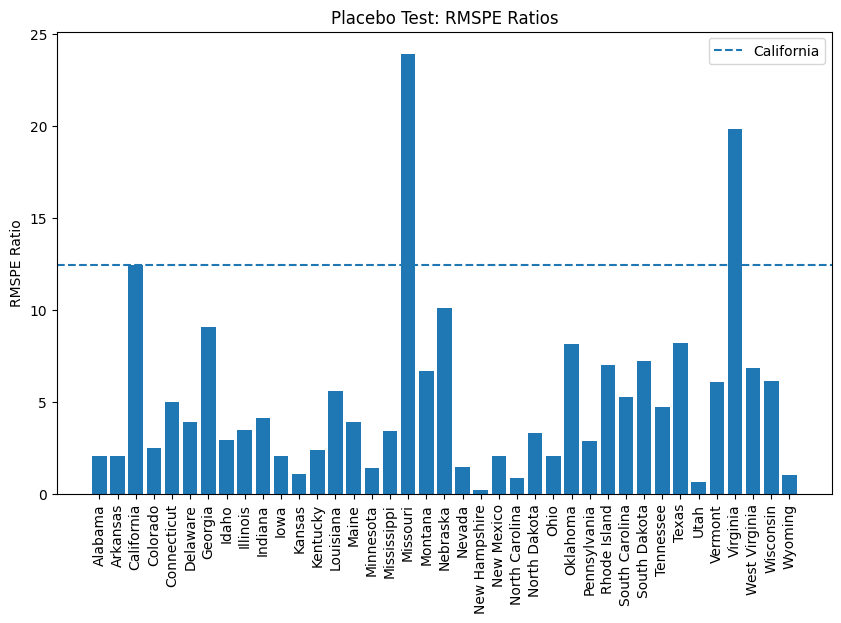

In [148]:
plt.figure(figsize=(10, 6))

plt.bar(
    placebo_df["state"],
    placebo_df["RMSPE_Ratio"]
)

plt.axhline(
    y=12.44,
    linestyle="--",
    label="California"
)

plt.xticks(rotation=90)
plt.ylabel("RMSPE Ratio")
plt.title("Placebo Test: RMSPE Ratios")
plt.legend()

plt.show()

The **placebo test** shows that California had a relatively high **RMSPE ratio** of 12.44. Only Missouri and Virginia had higher ratios, while most states had lower ratios. This suggests that California experienced a relatively large change after 1989, although the effect was not statistically significant at the 5% level.

## Synthetic Control Weights

In [161]:
weights_df_filtered = weights_df[
    weights_df["weight"] > 0.0001
]

print(weights_df_filtered)

            state    weight
32           Utah  0.393904
17        Montana  0.231844
19         Nevada  0.204924
3     Connecticut  0.109089
20  New Hampshire  0.045427
2        Colorado  0.014811


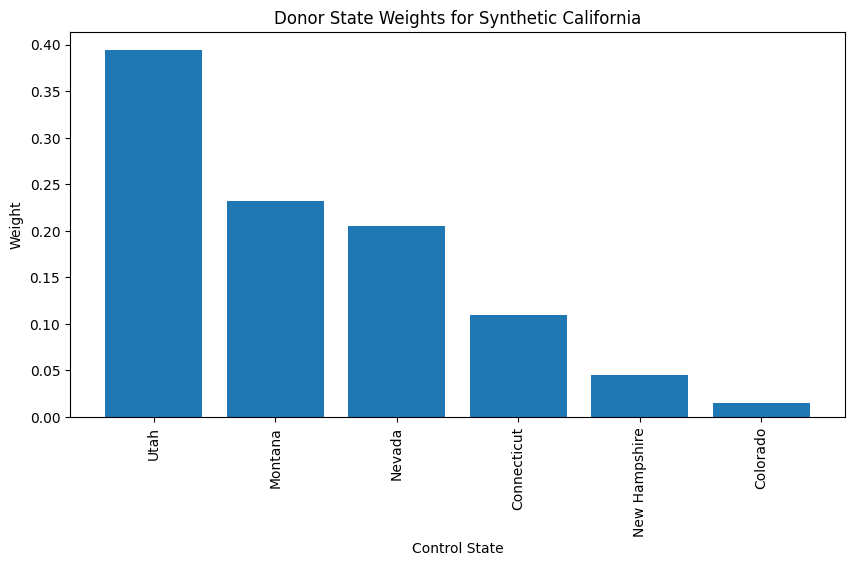

In [163]:
plt.figure(figsize=(10, 5))

plt.bar(
    weights_df_filtered["state"],
    weights_df_filtered["weight"]
)

plt.xticks(rotation=90)
plt.xlabel("Control State")
plt.ylabel("Weight")
plt.title("Donor State Weights for Synthetic California")

plt.show()

The **Synthetic Control Method** assigned different weights to the control states to construct Synthetic California. Utah received the highest weight (39.39%), followed by Montana (23.18%), Nevada (20.49%), and Connecticut (10.91%). New Hampshire (4.54%) and Colorado (1.48%) received smaller weights.

This indicates that Synthetic California was mainly constructed from a small group of control states rather than an equal average of all control states. Utah made the largest contribution to the synthetic control, with a weight of 39.39%.


### Conclusion

The **Synthetic Control Method** provides evidence that Proposition 99 had a substantial effect on cigarette consumption in California. Before 1989, actual cigarette sales closely matched the synthetic control, with a **pre-treatment RMSPE** of 1.66. After the policy was introduced, actual cigarette sales declined considerably more than those of Synthetic California.

The estimated **average treatment effect** was −19.51, indicating that cigarette sales in California were, on average, 19.51 units lower than the estimated counterfactual level after Proposition 99. The **placebo analysis** also showed a large **RMSPE ratio** of 12.44, suggesting that California experienced an unusually large decline compared with the control states.

Overall, the results suggest that Proposition 99 contributed significantly to the reduction in cigarette sales in California.
